# Is beer recession-proof? 🍺
### "People drink more when times are hard" — do the beer stocks actually hold up?

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Counter--cyclical%3F: Busted](https://img.shields.io/badge/Counter--cyclical%3F-Busted-8b949e?style=flat-square)

It's one of those things everyone *knows*: when the economy tanks, people don't stop drinking — they drink **more**. Cheap comfort, a pint at the end of a bad week. So beer must be **recession-proof**: while the market crashes, a brewer's stock should sail through, a safe harbour you can actually own.

This notebook puts that folklore on the clock. We take the two beer stocks you can buy — **Molson Coors (`TAP`)** and **Boston Beer (`SAM`, the Sam Adams people)** — line them up next to the **S&P 500**, and ask two blunt questions: *when the market falls, do they fall less?* and *when the economy is actually in recession, do they beat the index?*

> 📓 **Plain-language layer.** Want the downside-beta regressions, the Newey-West alpha and the recession-window *t*-stats? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice — and a data note.** Prices are real (month-end, yfinance). The recession dates are the **NBER**'s official ones (a cited, dated set of facts — not a live feed). Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from beer_recession import data, strategy as st

HAVE_PRICES = data.have_prices()
PX = data.load_prices() if HAVE_PRICES else None
print("price cache present:", HAVE_PRICES,
      "| NBER recessions in sample:", [r[0] for r in data.NBER_RECESSIONS])

# frozen headline numbers (mirror of docs/results.md)
R = {'win': '1995 → 2026', 'n_spy': 377, 'n_sam': 367, 'tap_cagr': 7.32, 'tap_vol': 26.9, 'tap_sharpe': 0.4, 'tap_mdd': -66.4, 'sam_cagr': 6.52, 'sam_vol': 37.4, 'sam_sharpe': 0.36, 'sam_mdd': -85.4, 'spy_cagr': 11.12, 'spy_vol': 15.1, 'spy_sharpe': 0.78, 'spy_mdd': -50.8, 'tap_alpha': 3.25, 'tap_beta': 0.64, 'tap_t': 0.71, 'tap_p': 0.48, 'sam_alpha': 5.91, 'sam_beta': 0.68, 'sam_t': 0.84, 'sam_p': 0.403, 'tap_down_beta': 0.6, 'tap_up_beta': 0.7, 'tap_asym': -0.1, 'tap_def': 1, 'sam_down_beta': 0.87, 'sam_up_beta': 0.79, 'sam_asym': 0.09, 'sam_def': 0, 'n_down': 130, 'n_up': 247, 'rec_n': 31, 'tap_rec_mean': -1.44, 'tap_rec_excess': 0.25, 'tap_rec_t': 0.14, 'tap_rec_p': 0.891, 'tap_rec_cum': -48.1, 'sam_rec_mean': 2.42, 'sam_rec_excess': 4.12, 'sam_rec_t': 1.87, 'sam_rec_p': 0.071, 'sam_rec_cum': 64.3, 'spy_rec_mean': -1.7, 'spy_rec_cum': -45.6, 'rec_labels': ['2001 dot-com', '2008 GFC', '2020 COVID'], 'tap_by_rec': [-13.8, -19.3, -25.4], 'sam_by_rec': [40.8, -10.8, 30.9], 'spy_by_rec': [-7.1, -35.5, -9.2], 'tap_wealth': 9.19, 'sam_wealth': 6.91, 'spy_wealth': 27.45, 'hold_yrs': 31.4, 'nber_lag': 12, 'syn_down': 0.48, 'syn_up': 0.77, 'syn_plant_down': 0.5, 'syn_plant_up': 1.0}


price cache present: True | NBER recessions in sample: ['2001 dot-com', '2008 GFC', '2020 COVID']


## The answer first

| Question | Answer |
|---|---|
| Do beer stocks fall *less* than the market? | **Sometimes — and only one of them.** Molson Coors is a low-beta stock (β≈0.64), so it swings less than the S&P. But Boston Beer's down-market beta (0.87) is *higher* than its up-market beta (0.79) — the **opposite** of defensive. |
| Do they beat the S&P *in a recession*? | **No, not reliably.** In 2 of the 3 recessions, Molson Coors fell **more** than the S&P; over all recession months it still ended down **-48%**. Boston Beer's apparent edge is two lucky craft-beer rallies, not a beer effect (*t* = 1.87, below the bar). |
| Is 'recession-proof beer' real? | **It's folklore.** The only real thing here is *low beta* — which isn't the same as counter-cyclical, and which you can buy more cheaply elsewhere. |
| Would you have been richer holding beer? | **Not even close.** \$1 in the S&P became **\$27**; in Molson Coors **\$9**, in Boston Beer **\$7**. |

> The barstool wisdom mixes up two different things: *low beta* (real, boring) and *counter-cyclical* (the exciting claim — and not there).

## 1 · The claim

> *"Beer is recession-proof. When people lose their jobs they don't cancel the beer — they cancel the vacation and buy a six-pack instead. So a brewer is a defensive stock: it holds up when everything else is falling apart. Alcohol is the last thing people give up."*

It's a genuinely *steelman-able* idea. "Sin" and staple consumption really is stickier than, say, cars or holidays — brewers sell a cheap, habitual, everyday product. The finance version of the folklore is specific and testable: a beer stock should have a **low downside beta** (it participates less in market falls) and should **out-return the S&P during recessions**. If that's true, it's a free defensive tilt you can hold forever.

## 2 · So what?

If it were true, a beer stock would be a rare thing: an equity that *cushions* your portfolio exactly when you need it — when the market is crashing and a recession is biting. That's worth real money: lower drawdowns, a smoother ride, a genuine diversifier you can hold instead of bonds. But notice the sleight of hand. "Beer sales hold up in a recession" is a claim about **volumes**. "Beer *stocks* beat the market in a recession" is a claim about **prices** — and a stock price already has the whole recession, and everyone's opinion about beer volumes, baked in. Those two things need not agree at all. We can check the second one directly.

## 3 · How would we even know?

Three honest tests, each against the S&P 500 (SPY):

1. **Do they fall less?** Split every month into "market up" and "market down," and measure how much each beer stock moves *on the way down* versus *on the way up*. A truly defensive name drops less than it climbs.
2. **Do they beat the index in a recession?** Take the actual NBER recession months (2001, 2008, 2020) and compare each beer stock's return to the S&P's, head-to-head.
3. **Could you even trade it?** The NBER only *declares* a recession many months after it starts — so "rotate into beer when the recession hits" is a rule you can't actually follow in real time.

**What would make us say "recession-proof"?** A clear, consistent tendency to fall less *and* beat the index across recessions — not one lucky window. Anything less is a barstool story.

## 4 · The teardown — let's actually look

**First: do they fall less than the market?** For each stock we measure its *bear-market beta* (how much it moves in months the S&P is down) against its *bull-market beta*. Defensive means the down-bar is **shorter** than the up-bar.

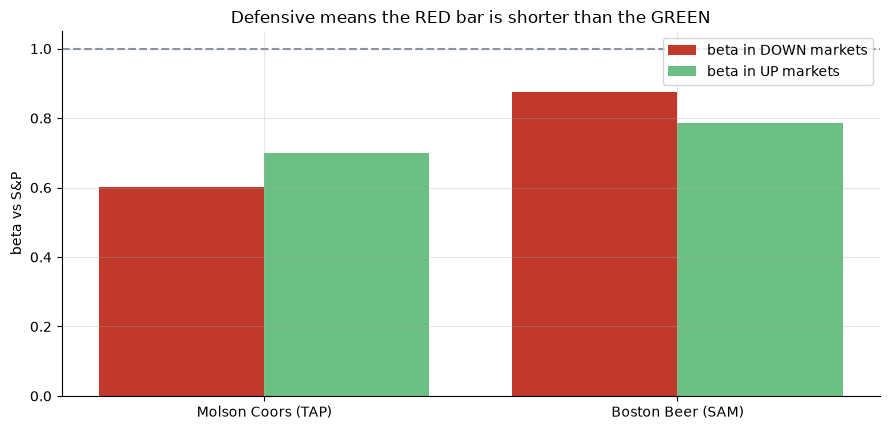

TAP: down-beta 0.60 vs up-beta 0.70  -> defensive
SAM: down-beta 0.87 vs up-beta 0.79  -> NOT defensive


In [2]:
if HAVE_PRICES:
    spy_r = PX['SPY'].pct_change().dropna()
    bb = {t: st.bull_bear_beta(PX[t].pct_change().dropna(), spy_r, split=0.0) for t in ['TAP','SAM']}
    tap_d, tap_u = bb['TAP']['down_beta'], bb['TAP']['up_beta']
    sam_d, sam_u = bb['SAM']['down_beta'], bb['SAM']['up_beta']
else:
    tap_d, tap_u = R['tap_down_beta'], R['tap_up_beta']
    sam_d, sam_u = R['sam_down_beta'], R['sam_up_beta']
x = np.arange(2); fig, ax = plt.subplots(figsize=(9, 4.4))
ax.bar(x-.2, [tap_d, sam_d], .4, color=RED, label='beta in DOWN markets')
ax.bar(x+.2, [tap_u, sam_u], .4, color=GREEN, alpha=.7, label='beta in UP markets')
ax.axhline(1.0, ls='--', c=GREY); ax.set_xticks(x); ax.set_xticklabels(['Molson Coors (TAP)','Boston Beer (SAM)'])
ax.set_ylabel('beta vs S&P'); ax.set_title('Defensive means the RED bar is shorter than the GREEN'); ax.legend()
plt.tight_layout(); plt.show()
print(f'TAP: down-beta {tap_d:.2f} vs up-beta {tap_u:.2f}  -> {"defensive" if tap_d<tap_u else "NOT defensive"}')
print(f'SAM: down-beta {sam_d:.2f} vs up-beta {sam_u:.2f}  -> {"defensive" if sam_d<sam_u else "NOT defensive"}')

Split decision. Molson Coors *is* the mild defensive the folklore imagines — its down-beta (**0.60**) sits below its up-beta (**0.70**). But Boston Beer does the **opposite**: it falls *harder* than it rises (**0.87** down vs **0.79** up). Two beer stocks, two opposite answers — not the signature of a real "beer is defensive" law. And note both betas are *below 1*: these are simply low-beta stocks, which is a different, more boring thing than counter-cyclical.

**Now the direct test: the recessions themselves.** Here is how each stock did, compounded, inside each of the three NBER recessions — head-to-head with the S&P.

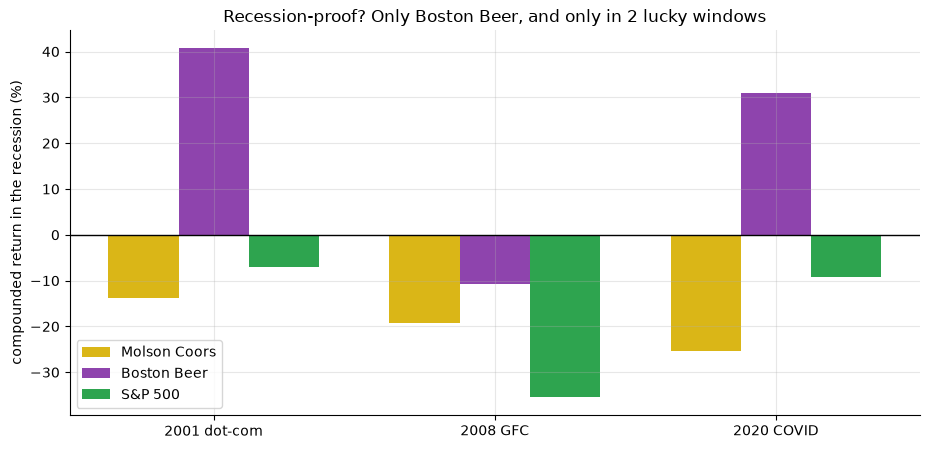

2001 dot-com    TAP  -13.8%  SAM  +40.8%  SPY   -7.1%
2008 GFC        TAP  -19.3%  SAM  -10.8%  SPY  -35.5%
2020 COVID      TAP  -25.4%  SAM  +30.9%  SPY   -9.2%


In [3]:
labels = R['rec_labels']
if HAVE_PRICES:
    tb = st.recession_breakdown(PX['TAP'].pct_change().dropna(), spy_r, data.NBER_RECESSIONS)
    sb = st.recession_breakdown(PX['SAM'].pct_change().dropna(), spy_r, data.NBER_RECESSIONS)
    tapv=[tb[l]['stock']*100 for l in labels]; samv=[sb[l]['stock']*100 for l in labels]; spyv=[tb[l]['bench']*100 for l in labels]
else:
    tapv, samv, spyv = R['tap_by_rec'], R['sam_by_rec'], R['spy_by_rec']
x = np.arange(3); fig, ax = plt.subplots(figsize=(9.4, 4.6))
ax.bar(x-.25, tapv, .25, color=AMBER, label='Molson Coors')
ax.bar(x,      samv, .25, color='#8e44ad', label='Boston Beer')
ax.bar(x+.25, spyv, .25, color=GREEN, label='S&P 500')
ax.axhline(0, c='k', lw=1); ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('compounded return in the recession (%)')
ax.set_title('Recession-proof? Only Boston Beer, and only in 2 lucky windows'); ax.legend()
plt.tight_layout(); plt.show()
for i,l in enumerate(labels): print(f'{l:14s}  TAP {tapv[i]:+6.1f}%  SAM {samv[i]:+6.1f}%  SPY {spyv[i]:+6.1f}%')

Look at what actually happened. Molson Coors — the *defensive* one — fell **more** than the S&P in 2001 and in 2020; it only "won" the 2008 crash. Boston Beer's two big green bars (2001, 2020) are a small craft-beer growth stock ripping higher for reasons that have nothing to do with recession beer-drinking — and in **2008, the deepest recession**, it *fell* too. There is no consistent "beer beats the market when times are hard" here.

**So does the aggregate "recession outperformance" survive?** Pool every recession month and compare each stock's average monthly return to the S&P's.

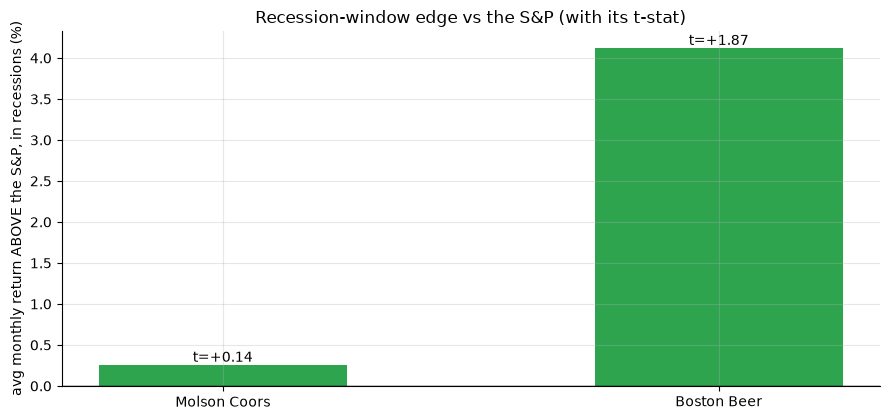

TAP recession excess +0.25%/mo  t=+0.14  (basically zero)
SAM recession excess +4.12%/mo  t=+1.87  (below the |t|>=2 bar)


In [4]:
if HAVE_PRICES:
    tre = st.recession_excess_t(PX['TAP'].pct_change().dropna(), spy_r, data.recession_mask)
    sre = st.recession_excess_t(PX['SAM'].pct_change().dropna(), spy_r, data.recession_mask)
    tap_ex,tap_t = tre['mean_excess']*100, tre['t']
    sam_ex,sam_t = sre['mean_excess']*100, sre['t']
else:
    tap_ex,tap_t = R['tap_rec_excess'], R['tap_rec_t']
    sam_ex,sam_t = R['sam_rec_excess'], R['sam_rec_t']
fig, ax = plt.subplots(figsize=(9, 4.3))
cols=[GREEN if v>0 else RED for v in [tap_ex, sam_ex]]
ax.bar(['Molson Coors','Boston Beer'], [tap_ex, sam_ex], .5, color=cols)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('avg monthly return ABOVE the S&P, in recessions (%)')
for i,(v,t) in enumerate(zip([tap_ex,sam_ex],[tap_t,sam_t])): ax.annotate(f't={t:+.2f}',(i,v),ha='center',va='bottom' if v>=0 else 'top')
ax.set_title('Recession-window edge vs the S&P (with its t-stat)')
plt.tight_layout(); plt.show()
print(f'TAP recession excess {tap_ex:+.2f}%/mo  t={tap_t:+.2f}  (basically zero)')
print(f'SAM recession excess {sam_ex:+.2f}%/mo  t={sam_t:+.2f}  (below the |t|>=2 bar)')

Molson Coors' recession edge is **essentially zero** (*t* = 0.14). Boston Beer's looks bigger (**+4.1%/mo**) but *t* = **1.87** — under the bar we set for "real," and, as the chart above showed, it's two idiosyncratic rallies rather than a repeatable beer effect. Neither clears the line.

**And the part the barstool never mentions: what did "defense" cost you?** Even if a stock wobbles less, it's a bad trade if it barely grows. Here's \$1 left in each for the whole 31 years.

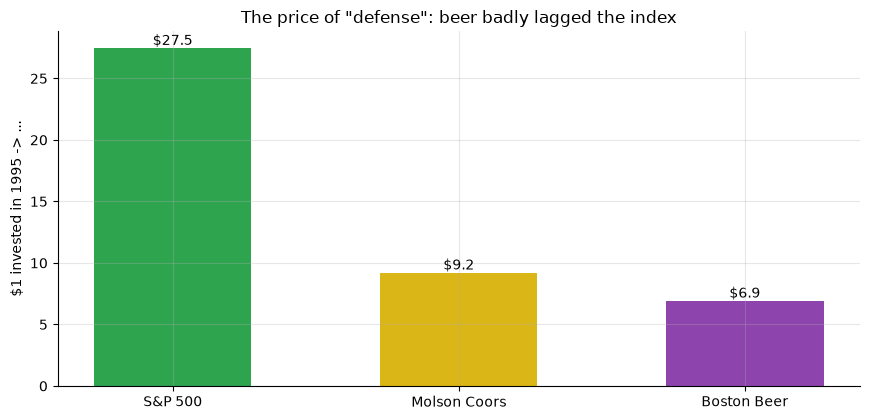

$1 -> S&P $27.45  |  Molson Coors $9.19  |  Boston Beer $6.91


In [5]:
if HAVE_PRICES:
    ends = [st.terminal_wealth(PX[t]) for t in ['SPY','TAP','SAM']]
else:
    ends = [R['spy_wealth'], R['tap_wealth'], R['sam_wealth']]
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.bar(['S&P 500','Molson Coors','Boston Beer'], ends, .55, color=[GREEN, AMBER, '#8e44ad'])
for i,v in enumerate(ends): ax.annotate(f'${v:.1f}',(i,v),ha='center',va='bottom')
ax.set_ylabel('$1 invested in 1995 -> ...'); ax.set_title('The price of "defense": beer badly lagged the index')
plt.tight_layout(); plt.show()
print(f"$1 -> S&P ${ends[0]:.2f}  |  Molson Coors ${ends[1]:.2f}  |  Boston Beer ${ends[2]:.2f}")

The index turned \$1 into **\$27**. The beer stocks? **\$9** and **\$7** — roughly a *third* of the index, with *deeper* worst-case drawdowns. Whatever mild cushioning Molson Coors offered on the way down, you paid for it many times over in growth you gave up.

## 5 · The verdict

- **Signal — None.** No significant excess return anywhere: the recession-window edge doesn't clear the bar (best is Boston Beer at *t* = 1.87), the CAPM alphas are insignificant, and the two names disagree on whether beer is even defensive.
- **Tradability — Mirage.** You can't know you're *in* a recession until the NBER says so months later, and holding beer "for defense" cost you two-thirds of the index's return over 31 years.
- **Counter-cyclical? — Busted.** The only real effect is *low beta* (Molson Coors), which is not the same as counter-cyclical — and Boston Beer isn't even low-beta on the downside.

## 6 · Could you actually trade it? — the honest bottom line

Suppose you *believed* it in 1995 and put your \$10,000 into beer "for safety." Where do you land in 2026 versus someone who just bought the index and forgot about it?

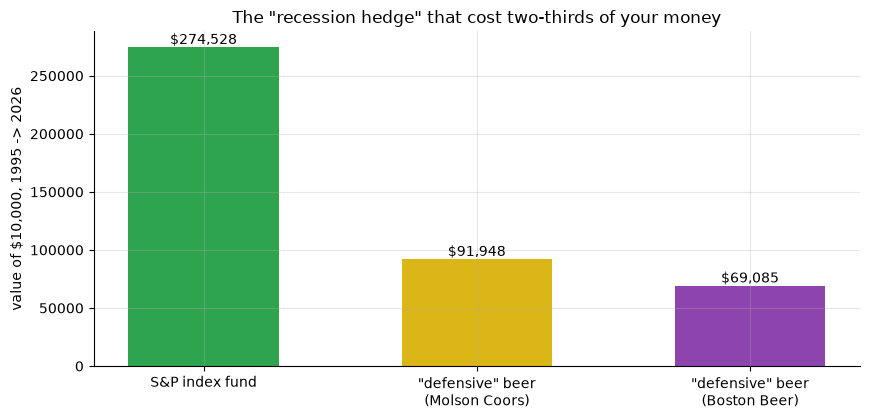

S&P            $274,528
Molson Coors   $91,948
Boston Beer    $69,085


In [6]:
start=10_000.0
if HAVE_PRICES:
    mult=[st.terminal_wealth(PX[t]) for t in ['SPY','TAP','SAM']]
else:
    mult=[R['spy_wealth'],R['tap_wealth'],R['sam_wealth']]
ends=[start*m for m in mult]
fig, ax = plt.subplots(figsize=(8.8,4.3))
ax.bar(['S&P index fund','"defensive" beer\n(Molson Coors)','"defensive" beer\n(Boston Beer)'], ends,
       color=[GREEN, AMBER, '#8e44ad'], width=.55)
for i,v in enumerate(ends): ax.annotate(f'${v:,.0f}',(i,v),ha='center',va='bottom')
ax.set_ylabel('value of $10,000, 1995 -> 2026'); ax.set_title('The "recession hedge" that cost two-thirds of your money')
plt.tight_layout(); plt.show()
for l,v in zip(['S&P','Molson Coors','Boston Beer'], ends): print(f'{l:14s} ${v:,.0f}')

The index investor ends with roughly **three times** what the beer holder does. And the one moment the hedge was supposed to earn its keep — a recession — is exactly when you *couldn't act on it*: the NBER declared the 2008 recession a full year after it began and back-dated the 2020 trough more than a year later. "Rotate into beer when the recession hits" is a rule you can only follow with a time machine. The recession-proof-beer trade is a story you tell at the bar, not a position you can hold.

## 7 · Going further 🚪

- **Widen the beer aisle.** Add Anheuser-Busch InBev (`BUD`), Constellation (`STZ`), Heineken (`HEINY`), Diageo (`DEO`) — does *any* brewer show a consistent recession edge, or is it always one lucky name?
- **Volumes vs prices.** Pull actual beer shipment data (the folklore's real claim) and see whether even *volumes* rise in recessions — spoiler: it's mostly a shift to cheaper brands, not more litres.
- **The staples cousin.** The same test on tobacco (`MO`, `PM`) or discount retail is the natural next study — is *anything* truly counter-cyclical, or just low-beta? (see [docs/references.md](../docs/references.md)).

*Think a specific brewer beat the S&P net of everything through a recession you can name? Pull its tape, mark the NBER window, and show it — then check it wasn't one idiosyncratic rally doing all the work.*